# Capillary-breakup (CaBER) video analysis — `cabervideo` quickstart

End-to-end demo of filament-thinning analysis with the `cabervideo` helper module:
load a capillary-breakup video → track the filament radius frame by frame →
calibrate pixels to metres → fit the linear thinning regime → extensional viscosity & Trouton ratio.

> ⚠️ **Kernel requirement.** This notebook needs OpenCV (`cv2`), which has no Pyodide build,
> so it cannot run in the JupyterLite in-browser kernel. Run it on a full Python kernel
> (local Jupyter, Colab, Binder). The interactive bounding-box selector additionally needs
> an interactive matplotlib backend (`ipympl`); a programmatic mask is used by default so the
> notebook also runs headless.

`cabervideo` is a single-file helper that lives with this demo in the rheolite repository
(`content/capyllarybreakup/cabervideo.py`) — it is not on PyPI, so the notebook below
fetches it automatically if it is not already next to the notebook.

In [24]:
%pip install -q opencv-python ipywidgets lmfit openpyxl pillow

Note: you may need to restart the kernel to use updated packages.


c:\Users\caggioni.m\rheolite\.venv\Scripts\python.exe: No module named pip


In [1]:
# --- fetch the cabervideo helper module (single file in the rheolite repo) ---
import importlib, pathlib, sys, urllib.request

CABER_URL = ("https://raw.githubusercontent.com/rheopy/rheolite/main/"
             "content/capyllarybreakup/cabervideo.py")

def _ensure_cabervideo():
    try:
        import cabervideo  # noqa
        return
    except ImportError:
        pass
    dest = pathlib.Path('cabervideo.py')
    print(f"downloading cabervideo.py from the rheolite repo ...")
    urllib.request.urlretrieve(CABER_URL, dest)
    print(f"saved to {dest.resolve()}")

_ensure_cabervideo()
import cabervideo as cv
print("cabervideo imported:", [n for n in dir(cv) if not n.startswith('_')])


cabervideo imported: ['CaberVideo', 'Image', 'bbox_select', 'calibrate_res_table', 'clear_output', 'cv2', 'display', 'fit_linear_caber', 'lmfit', 'np', 'pd', 'plt', 'widgets']


## Test video

Upload your own CaBER `.mp4` below, or leave the uploader empty to use the bundled
capillary-breakup video.

In [2]:
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path

upload = widgets.FileUpload(accept='.mp4', multiple=False,
                            description='Upload CaBER mp4')
display(upload)


FileUpload(value=(), accept='.mp4', description='Upload CaBER mp4')

In [4]:
# Use the uploaded video when present, otherwise the synthetic one.
upload = globals().get('upload')
files = getattr(upload, 'value', None) or ()
if len(files):
    info = files[0]
    video_path = info['name']
    Path(video_path).write_bytes(info['content'])
    print(f"using uploaded video: {video_path} ({len(info['content'])/1e6:.1f} MB)")
else:
    video_path = '6000cp_viscosity_standard.mp4'
    print(f"no upload — using video: {video_path}")


no upload — using video: 6000cp_viscosity_standard.mp4


loaded 6000cp_viscosity_standard.mp4: 468 frames


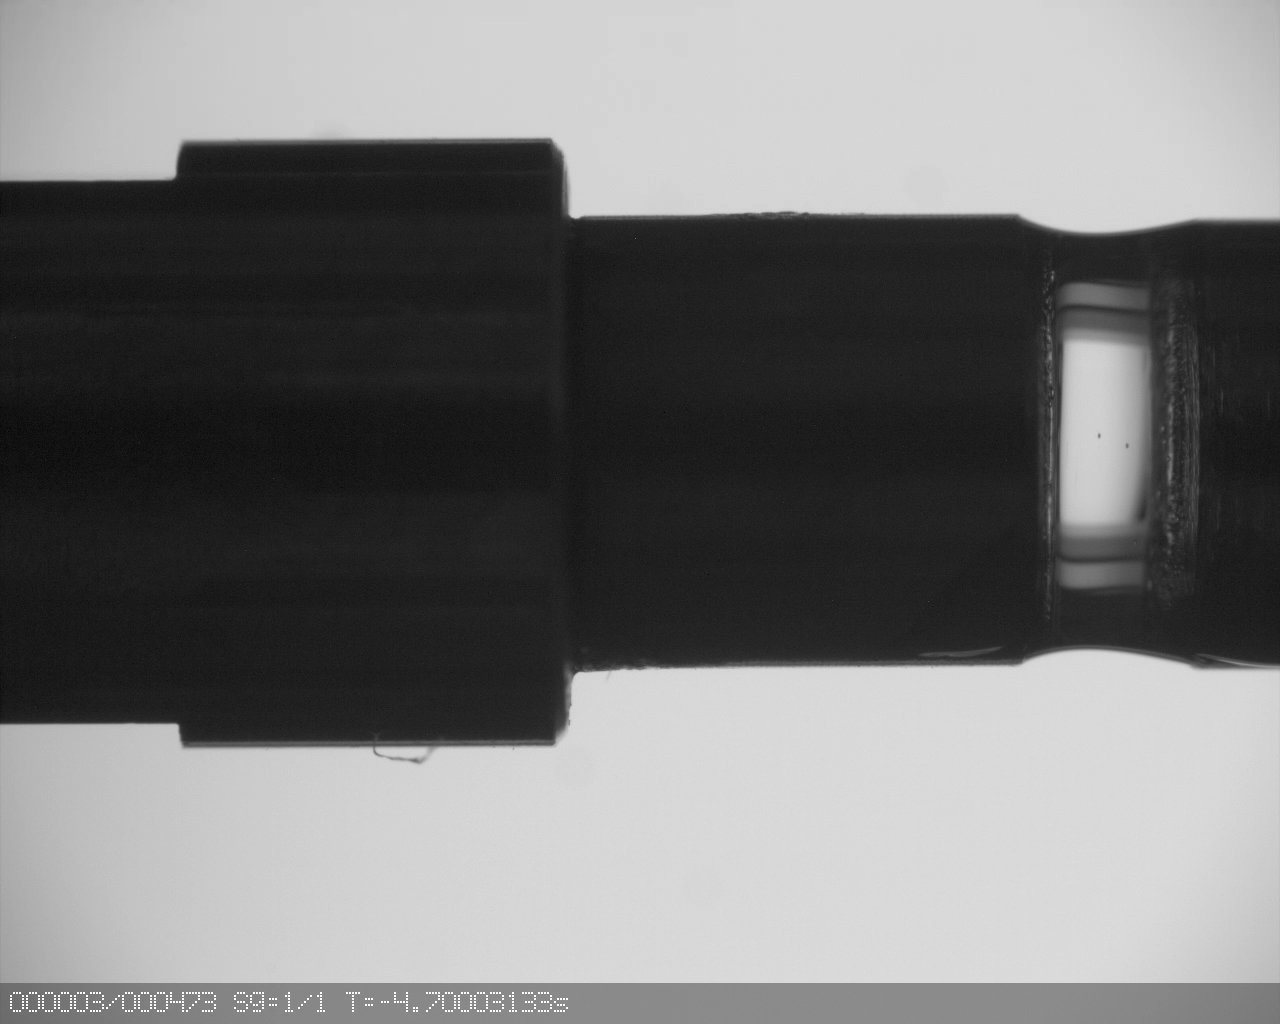

In [5]:
test_video = cv.CaberVideo(video_path)
print(f"loaded {video_path}: {test_video.num_frames} frames")
test_video.show_frame(0)  # PIL image of the first frame


## Region of interest

`find_radius` flood-fills the bright background from the frame edges, so the default
full-frame mask works when the plates/filament do not touch the image border (as in the
synthetic video and in the original demo video). For interactive use with a desktop
matplotlib backend you can draw a bounding box instead — uncomment the lines below
(requires `ipympl`).

mask: (slice(0, 1023, None), slice(0, 1279, None))


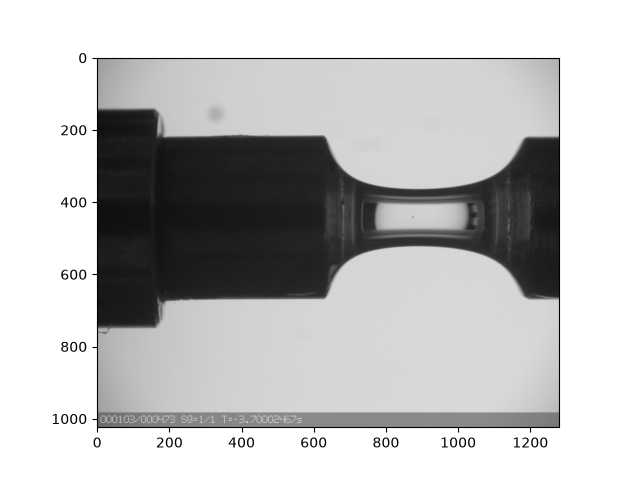

In [ ]:
from ty_extensions._internal import Unknown
test_video.reset_mask()  # full frame

# --- optional interactive bounding-box selection (desktop kernel + ipympl only) ---
get_ipython().run_line_magic('matplotlib', 'ipympl')
bs = cv.bbox_select(test_video[100])   # draw the box, then:
test_video.mask: Unknown = bs.mask

print("mask:", test_video.mask)

In [13]:
test_video.mask: Unknown = bs.mask


NameError: name 'Unknown' is not defined

In [14]:
import io
import ipywidgets as widgets
from IPython.display import display



def _frame_png(i):
    buf = io.BytesIO()
    test_video.show_frame(i).save(buf, format='PNG')
    return buf.getvalue()

img_w = widgets.Image(value=_frame_png(0), format='png')
slider = widgets.IntSlider(min=0, max=test_video.num_frames - 1, step=1,
                           value=0, description='Frame:', continuous_update=False)
slider.observe(lambda ch: setattr(img_w, 'value', _frame_png(ch['new'])), names='value')
display(widgets.VBox([slider, img_w]))
print(f"frame inspector ready: {test_video.num_frames} frames")


frame inspector ready: 468 frames


## Track the filament radius

In [16]:
res_table = test_video.find_radius_all()
print(res_table.shape)
res_table.head(3)


c:\Users\caggioni.m\rheolite\content\capillarybreakup\cabervideo.py:120: RuntimeWarning: overflow encountered in scalar subtract
  return h-airwidth+2
c:\Users\caggioni.m\rheolite\content\capillarybreakup\cabervideo.py:120: RuntimeWarning: overflow encountered in scalar add
  return h-airwidth+2


(468, 3)


,frame_num,radius_pixels,filename
0,0,0,6000cp_viscosity_standard.mp4
1,1,0,6000cp_viscosity_standard.mp4
2,2,0,6000cp_viscosity_standard.mp4


In [17]:
res_table.tail(3)

,frame_num,radius_pixels,filename
465,465,0,6000cp_viscosity_standard.mp4
466,466,0,6000cp_viscosity_standard.mp4
467,467,0,6000cp_viscosity_standard.mp4


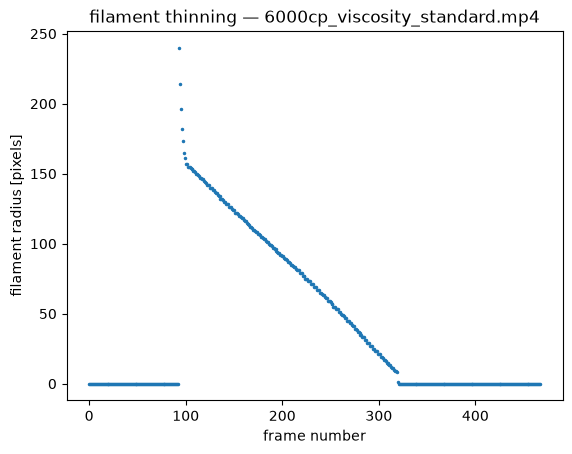

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(res_table['frame_num'], res_table['radius_pixels'], '.', ms=3)
ax.set_xlabel('frame number')
ax.set_ylabel('filament radius [pixels]')
ax.set_title(f"filament thinning — {res_table['filename'].iloc[0]}")
plt.show()


In [20]:
# pixels -> metres, frames -> seconds
res_table = cv.calibrate_res_table(res_table)
res_table[['frame_num', 't_s', 'radius_pixels', 'radius_m']].head(3)


,frame_num,t_s,radius_pixels,radius_m
0,0,0.00,0,0.0
1,1,0.01,0,0.0
2,2,0.02,0,0.0


# Analysis

Linear elasto-capillary thinning fit, based on [McKinley & Tripathi (2000), *How to extract the Newtonian viscosity from capillary breakup measurements in a filament rheometer*, J. Rheol. 44, 653–670](https://web.mit.edu/nnf/publications/GHM45.pdf).
The filament radius thins approximately linearly in the visco-capillary regime; the slope gives
the extensional viscosity and, together with the shear viscosity, the Trouton ratio.

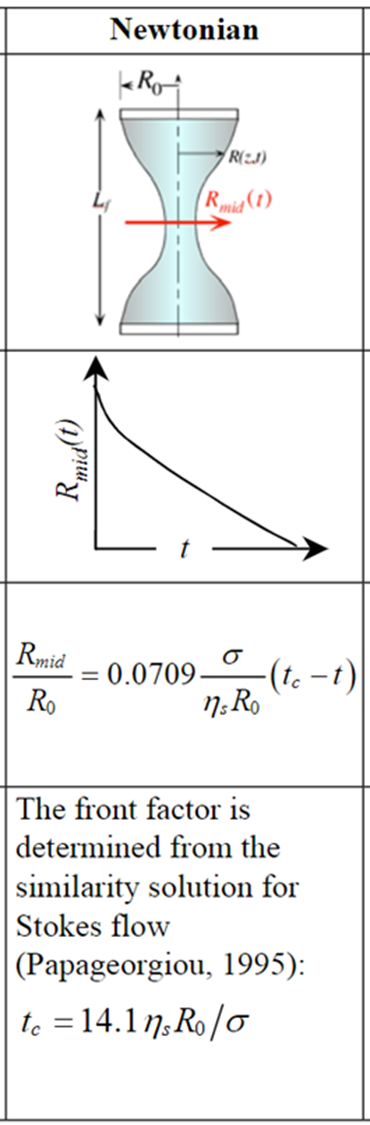


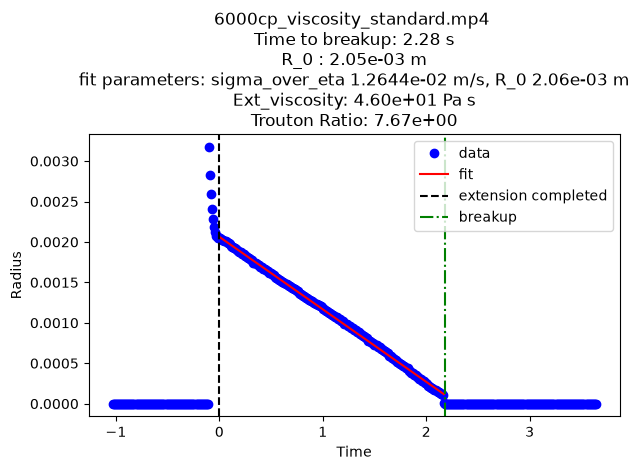

In [21]:
caber_results = cv.fit_linear_caber(res_table['t_s'],
                                    res_table['radius_m'],
                                    strike_len_s=0.1,
                                    fps=100,
                                    eta_shear=6,            # Pa s, from shear rheometry
                                    surface_tension=40e-3,  # N/m
                                    filename=res_table['filename'].iloc[0],
                                    show_plot=True)


In [22]:
for key, val in caber_results.items():
    if key == 'lmfit_result':
        continue
    print(f"{key:28s} {val}")
print()
print(caber_results['lmfit_result'].fit_report(min_correl=0.5))


time_to_breakup              2.28
Initial radius exp           0.002048458149779736
extensional_viscosity_pas    46.04759146669397
trouton_ration               7.674598577782329

[[Model]]
    Model(linear_rt)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 218
    # variables        = 2
    chi-square         = 5.9626e-08
    reduced chi-square = 2.7605e-10
    Akaike info crit   = -4796.28630
    Bayesian info crit = -4789.51731
    R-squared          = 0.99914140
[[Variables]]
    R_0:             0.00206407 +/- 2.2436e-06 (0.11%) (init = 3)
    sigma_over_eta:  0.01264447 +/- 2.5221e-05 (0.20%) (init = 1)
[[Correlations]] (unreported correlations are < 0.500)
    C(R_0, sigma_over_eta) = +0.8650


In [23]:
res_table.to_excel('res_table.xlsx')
print("saved res_table.xlsx")


saved res_table.xlsx


## Notes

- `find_radius` reports `frame_height − tallest_background_column + 2`; once the filament
  has broken and the background spans the full frame height, the value wraps to 0 — that is
  the breakup signature, not a measurement artefact to fit.
- `fit_linear_caber` fits the visco-capillary linear regime
  $R(t) \approx 0.0709\,(\sigma/\eta)\,(14.1\,R_0\,\eta/\sigma - t)$ and converts the slope
  into an extensional viscosity $\eta_{ext} = -\sigma / (2\dot R)$ and a Trouton ratio
  $\mathrm{Tr} = \eta_{ext}/\eta_{shear}$.
- For real experiments replace the synthetic video with your own upload; tune the
  binarisation `thresh` in `find_radius_all` and the calibration (`fps`, `mmperpix`)
  to your camera.